In [1]:
import pickle
import numpy as np
import trackpy as tp
import matplotlib.pyplot as plt
import matplotlib.colors as matplotlib_colors
from matplotlib import colormaps
from sklearn.linear_model import LinearRegression
import pandas as pd
from multiprocessing import Manager, Process
import os
from scipy.optimize import curve_fit

In [ ]:
confluence_save_file = 'pickles/confluence.pkl'
phase_save_file = 'pickles/phase.pkl'
adjust_save_file = 'pickles/adjust.pkl'

In [ ]:
focus_position=pd.read_table('Focusposition.txt', header=1).set_index('Elapsed').drop(columns='Date Time')
focus_position

,"B2, Image 1","B2, Image 2","C2, Image 1","C2, Image 2","D2, Image 1","D2, Image 2","E2, Image 1","E2, Image 2","B3, Image 1","B3, Image 2",...,"E6, Image 1","E6, Image 2","B7, Image 1","B7, Image 2","C7, Image 1","C7, Image 2","D7, Image 1","D7, Image 2","E7, Image 1","E7, Image 2"
Elapsed,,,,,,,,,,,,,,,,,,,,,
0,3330.1,3330.6,3385.9,3564.3,3420.2,3412.0,3673.7,3675.8,3451.9,3498.2,...,3621.1,3599.3,3500.8,3553.6,3355.1,3458.1,3690.1,3650.4,3709.7,3629.5
4,3625.1,3318.6,3389.3,3370.9,3410.0,3413.1,3713.3,3610.7,3326.3,3342.2,...,3604.2,3656.5,3313.5,3523.9,3354.6,3350.6,3617.4,3552.6,3626.1,3643.3
8,3538.1,3319.8,3378.6,3369.1,3414.0,3406.5,3651.3,3635.5,3324.8,3332.8,...,3597.5,3596.0,3441.0,3514.8,3352.6,3349.5,3612.7,3544.5,3606.3,3654.0
12,3642.7,3307.2,3367.5,3517.7,3408.0,3403.0,3636.4,3624.4,3315.8,3319.5,...,3659.6,3582.2,3305.2,3505.6,3349.5,3340.4,3602.2,3540.1,3602.5,3594.7
16,3308.9,3304.0,3360.3,3516.5,3401.7,3397.1,3709.2,3610.7,3314.3,3323.9,...,3587.2,3588.5,3425.1,3500.9,3343.4,3336.3,3572.5,3514.1,3604.0,3599.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,3234.0,3234.9,3273.6,3270.3,3313.6,3315.9,3359.6,4080.5,3226.8,3228.4,...,3322.9,3330.5,3216.9,3219.2,3249.1,3248.9,3292.3,3292.3,3329.4,3460.5
268,3231.8,3234.2,3273.2,3269.2,3312.6,3314.6,3357.7,4081.0,3225.4,3229.4,...,3321.1,3331.7,3216.8,3216.2,3249.7,3248.6,3291.9,3293.7,3327.9,3329.2
272,3232.7,3234.2,3271.9,3269.7,3310.5,3315.2,3359.0,4060.7,3226.9,3227.7,...,3321.6,3329.3,3216.6,3218.7,3248.6,3248.0,3291.4,3292.8,3328.4,3462.5


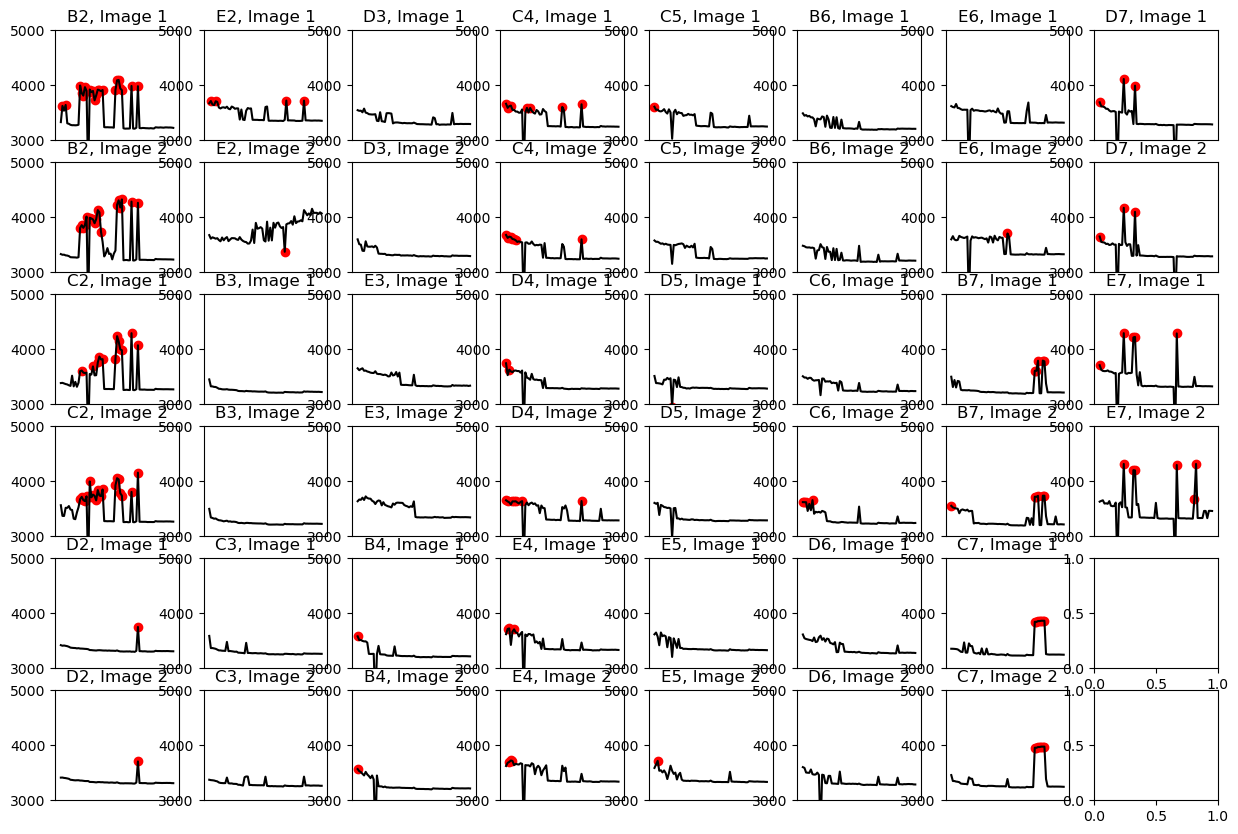

In [5]:
fig, axs = plt.subplots(6, 8, figsize=(6*2.5, 4*2.5))

median = {}
skip_times = {}
median_cutoff = 0.1

for i, well in enumerate(focus_position.columns):
    ax = axs[i%6, i//6]
    
    median[well] = np.median(focus_position[well])
    skip_times[well] = focus_position.index[((median[well] + median[well]*median_cutoff) < focus_position[well]) | ((median[well] - median[well]*median_cutoff) > focus_position[well])]

    ax.plot(focus_position.index, focus_position[well], color='black')
    ax.scatter(skip_times[well], focus_position.loc[skip_times[well], well], color='red')
    ax.set_xticks([])
    ax.set_title(well)
    ax.set_ylim((3000,5000))

In [6]:
with open(adjust_save_file, 'rb') as f:
    adjust = pickle.load(f)
adjust

({'B2_1': array([ 22,  21,  38,  55,  49,  47,  45,  35,  35,  54, -68, -68, -68,
         -67, -67, -68, -71, -64, -62, -11, -11, -12, -20, -20, -85, -86,
         -86, -87, -90, -90,  54,  55,  56,  32,  37,  63,  58,  60,  58,
          34,  36,  35,  38,  37,  38,  30,  34]),
  'C2_2': array([-75, -74, -75, -90, -91, -76, -84, -86, -85, -96, -98, -82, -27,
         -27, -28, -28, -28, -29, -31, -24, -23,  27,  25,  25,  17,  18,
         -49, -48, -47, -48, -48, -47,  96,  96,  96,  76,  76, 107, 101,
         101,  99,  78,  78,  79,  79,  78,  78,  76,  76]),
  'B2_2': array([-74, -78, -79, -94, -92, -75, -81, -83, -84, -94, -95, -76, -20,
         -29, -32, -30, -35, -33, -32, -35, -31, -23, -20,  30,  28,  27,
          21,  20, -46, -45, -43, -43, -49, -48,  96,  99,  99,  70,  79,
         104,  99, 102, 100,  75,  80,  76,  81,  82,  83,  73,  77]),
  'C2_1': array([ -94,  -97,  -96, -109, -105,  -87,  -92,  -82,  -83,  -88,  -89,
          -66,  -57,  -55,  -57,  -54,  -68,

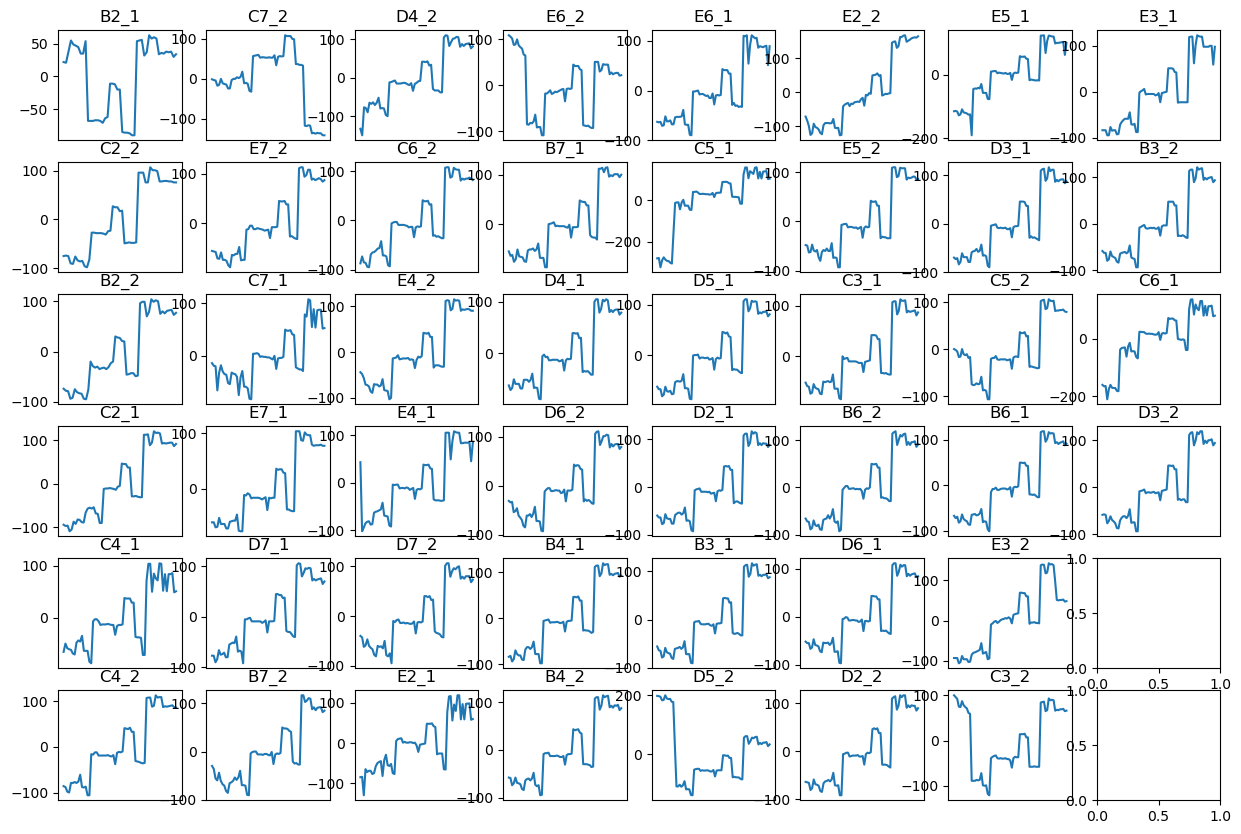

In [7]:
fig, axs = plt.subplots(6, 8, figsize=(6*2.5, 4*2.5))

for i, well in enumerate(adjust[0].keys()):
    ax = axs[i%6, i//6]

    ax.plot(range(adjust[0][well].shape[0]), adjust[0][well])

    ax.set_xticks([])
    ax.set_title(well)

In [8]:
with open(phase_save_file, 'rb') as f:
    phase = pickle.load(f)
with open(confluence_save_file, 'rb') as f:
    confluence = pickle.load(f)

In [9]:
def confluence_cmap(color):
    c = matplotlib_colors.to_rgb(color)
    return matplotlib_colors.LinearSegmentedColormap.from_list(
        f'confluence_cmap_{color}', 
        [(0, (c[0], c[1], c[2], 0)),
        (1, (c[0], c[1], c[2], 1))]
    )

In [10]:
def score_edge(edge, img):
    if edge < 1 or edge > img.shape[1]-1:
        return 0
    else:
        return np.mean(~img[:, :edge])+np.mean(img[:, edge:])

In [ ]:
def find_edge(img):
    m = -1
    best = 0

    max_edge = int(img.shape[1]*0.8)

    for i in range(1, max_edge-1):
        score = score_edge(i, img)
        if score > best:
            best = score
            m = i

    return m

def find_edge_for_process(well, dict):
    print(well)
    e = np.array([find_edge(confluence[well][i])for i in range(confluence[well].shape[0])])
    # e = e-e[0]
    dict[well] = e
    return dict[well]

# Growth ODE

$$
\frac{dN}{dt} = kN+m
$$
$$
N = \frac{(N_0 k + m)e^{kt}-m}{k}
$$

In [12]:
def growth_curve_all(t, n_0_1, n_0_2, k, m):
        return np.concatenate([
            ((n_0_1*k + m)*np.exp(k*t[:len(t)//2])-m)/k, 
            ((n_0_2*k + m)*np.exp(k*t[len(t)//2:])-m)/k
        ])

def growth_curve_split(t, n_0_1, n_0_2, k, m):
        return np.concatenate([
            ((n_0_1*k + m)*np.exp(k*t[:len(t)//2])-m)/k, 
            ((n_0_2*k + m)*np.exp(k*t[len(t)//2:])-m)/k
        ])

def growth_curve(t, n_0, k, m):
        return ((n_0*k + m)*np.exp(k*t)-m)/k

In [ ]:
with open('pickles/times.pkl', 'rb') as f: #times file
    times_str = pickle.load(f)
times_str

{'D3_1': array(['00d00h', '00d04h', '00d08h', '00d12h', '00d16h', '00d20h',
        '01d00h', '01d04h', '01d08h', '01d12h', '01d16h', '01d20h',
        '02d00h', '02d04h', '02d08h', '02d12h', '02d16h', '02d20h',
        '03d00h', '03d04h', '03d08h', '03d12h', '03d16h', '03d20h',
        '04d00h', '04d04h', '04d08h', '04d12h', '04d16h', '04d20h',
        '05d00h', '05d04h', '05d08h', '05d12h', '05d16h', '05d20h',
        '06d00h', '06d04h', '06d08h', '06d12h', '06d16h', '06d20h',
        '07d00h', '07d04h', '07d08h', '07d12h', '07d16h', '07d20h',
        '08d00h', '08d04h', '08d08h', '08d12h', '08d16h', '08d20h',
        '09d00h', '09d04h', '09d08h', '09d12h', '09d16h', '09d20h',
        '10d00h', '10d04h', '10d08h', '10d12h', '10d16h', '10d20h',
        '11d00h', '11d04h', '11d08h', '11d12h', '11d16h'], dtype='<U6'),
 'B2_2': array(['00d00h', '00d04h', '00d08h', '00d12h', '00d16h', '00d20h',
        '01d00h', '01d04h', '01d08h', '01d12h', '01d16h', '01d20h',
        '04d08h', '04d12h',

In [14]:
times = {well:[int(t.split('d')[0])*24+int(t.split('d')[1].split('h')[0]) for t in times_str[well]] for well in times_str.keys()}
times

{'D3_1': [0,
  4,
  8,
  12,
  16,
  20,
  24,
  28,
  32,
  36,
  40,
  44,
  48,
  52,
  56,
  60,
  64,
  68,
  72,
  76,
  80,
  84,
  88,
  92,
  96,
  100,
  104,
  108,
  112,
  116,
  120,
  124,
  128,
  132,
  136,
  140,
  144,
  148,
  152,
  156,
  160,
  164,
  168,
  172,
  176,
  180,
  184,
  188,
  192,
  196,
  200,
  204,
  208,
  212,
  216,
  220,
  224,
  228,
  232,
  236,
  240,
  244,
  248,
  252,
  256,
  260,
  264,
  268,
  272,
  276,
  280],
 'B2_2': [0,
  4,
  8,
  12,
  16,
  20,
  24,
  28,
  32,
  36,
  40,
  44,
  104,
  108,
  112,
  116,
  120,
  124,
  128,
  132,
  136,
  156,
  160,
  164,
  168,
  172,
  180,
  184,
  188,
  196,
  200,
  204,
  208,
  212,
  216,
  220,
  224,
  228,
  232,
  236,
  240,
  244,
  248,
  252,
  256,
  260,
  264,
  268,
  272,
  276,
  280],
 'E5_2': [0,
  4,
  12,
  16,
  20,
  24,
  28,
  32,
  36,
  40,
  44,
  48,
  52,
  56,
  60,
  64,
  68,
  72,
  76,
  80,
  84,
  88,
  92,
  96,
  100,
  104,
  108,


In [15]:
def left(img, edge):
    return np.concatenate([img[:, :edge], np.zeros((img.shape[0], img.shape[1]-edge))], axis=1)

def right(img, edge):
    return np.concatenate([np.zeros((img.shape[0], edge)), img[:, edge:]], axis=1)

B2_2


D7_1
E6_2
C4_1
E5_2
B7_2
D6_1
B4_2
B3_2
E3_2
C2_1
D3_1
B6_1
E2_1
C7_1
D4_1
D2_1
E4_1
D5_1
D4_2
C7_2
C6_2
D2_2
C5_2
E7_1
C2_2
C4_2
D7_2
C3_2
B3_1
E3_1
E5_1
E4_2
B4_1
B2_1
E2_2
B7_1
D6_2
E7_2
C6_1
C5_1
C3_1
E6_1
B6_2
D3_2
D5_2


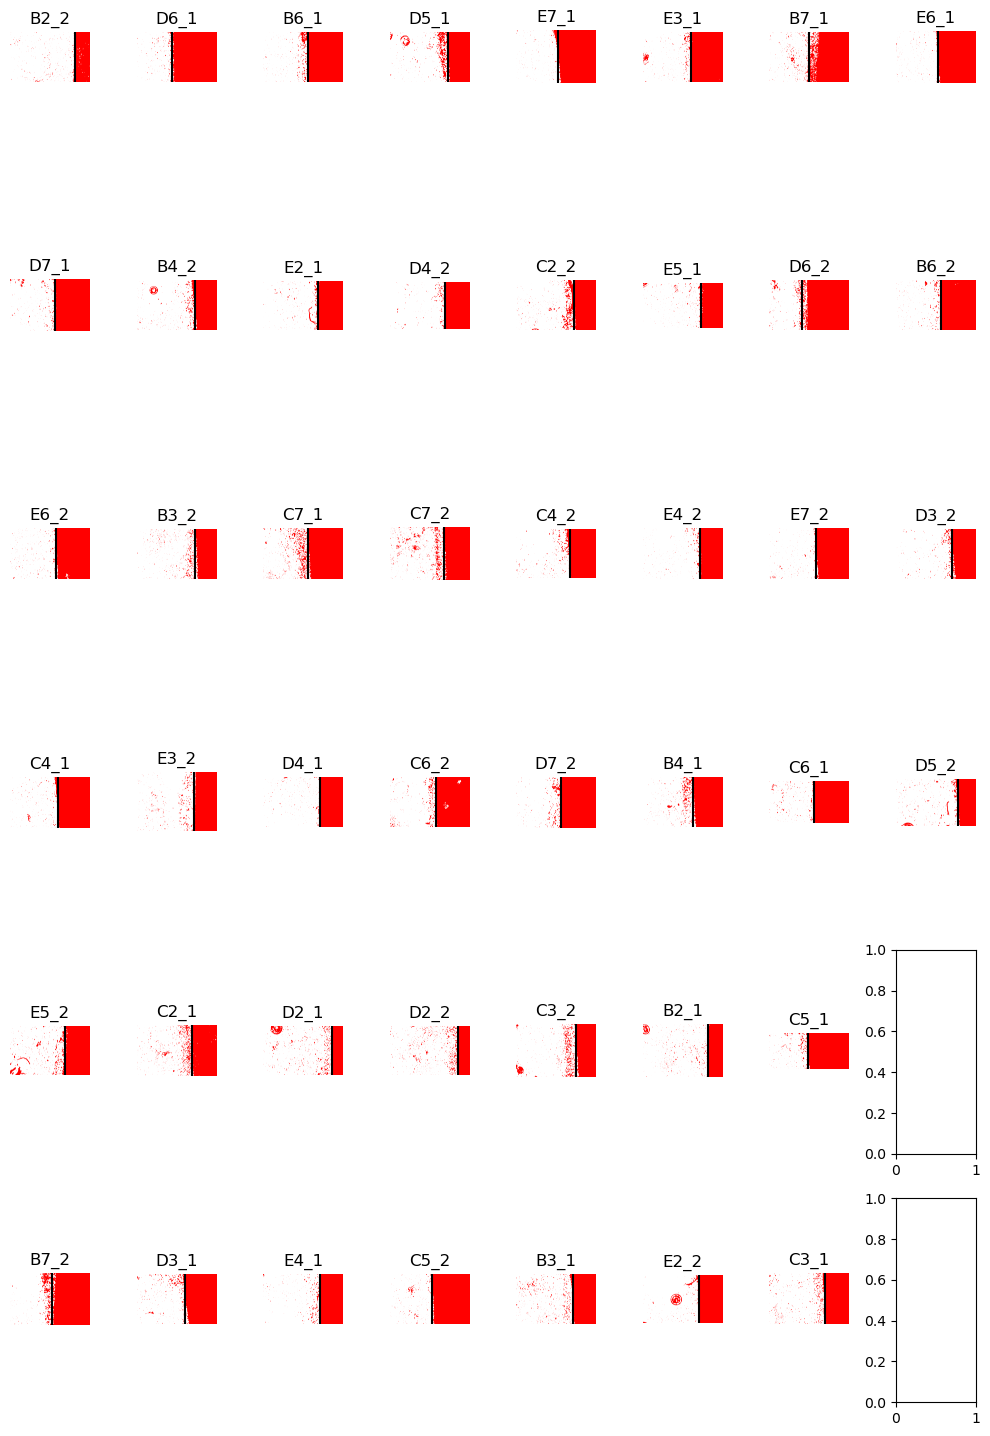

In [16]:
fig, axs = plt.subplots(6, 8, figsize=(10, 15))

edges = {}

for i, well in enumerate(confluence.keys()):
    print(well)
    edges[well] = find_edge(confluence[well][0])

    ax = axs[i%6, i//6]

    ax.imshow(confluence[well][6], cmap=confluence_cmap('red'))
    ax.vlines(edges[well], 0, confluence[well].shape[1], color='black')

    ax.set_title(well)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [17]:
exclude_wells = ['']

In [18]:
wells = np.unique([well[:2] for well in list(confluence.keys())])
wells = np.array([well for well in wells if well+'_1' not in exclude_wells or well+'_2' not in exclude_wells])
wells

array(['B2', 'B3', 'B4', 'B6', 'B7', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7',
       'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'E2', 'E3', 'E4', 'E5', 'E6',
       'E7'], dtype='<U2')

In [19]:
# skip first day
confluence = {well:confluence[well][~np.array([t.startswith('00') for t in times_str[well]]), :, :] for well in confluence.keys()}
phase = {well:phase[well][~np.array([t.startswith('00') for t in times_str[well]]), :, :] for well in confluence.keys()}
times = {well:[t-24 for t in times[well] if t >= 24] for well in times.keys()}
times_str = {well:[f'{int(t.split('d')[0])-1:02}'+'d'+t.split('d')[1] for t in times_str[well] if not t.startswith('00')] for well in times_str.keys()}

In [20]:
params = {}

for well in wells:
    print(well)
    if well+'_1' in exclude_wells or well+'_2' in exclude_wells:
        if well+'_1' in exclude_wells and well+'_2' in exclude_wells:
            continue
        elif well+'_1' in exclude_wells:
            params[well] = curve_fit(
                growth_curve, 
                times[well+'_2'], 
                np.array([np.mean(confluence[well+'_2'][i, :, :edges[well+'_2']]) for i in range(len(times[well+'_2']))]), 
                p0=[np.mean(confluence[well+'_2'][0, :, edges[well+'_2']]), 0.1, 0.1],
                bounds=(0, 1)
            )[0]
            params[well] = np.insert(params[well], 0, 0)
        else:
            params[well] = curve_fit(
                growth_curve, 
                times[well+'_1'], 
                np.array([np.mean(confluence[well+'_1'][i, :, :edges[well+'_1']]) for i in range(len(times[well+'_1']))]), 
                p0=[np.mean(confluence[well+'_1'][0, :, edges[well+'_1']]), 0.1, 0.1],
                bounds=(0, 1)
            )[0]
            params[well] = np.insert(params[well], 1, 0)
    else:
        params[well] = curve_fit(
            growth_curve_split, 
            times[well+'_1']+times[well+'_2'], 
            np.array([np.mean(confluence[well+'_1'][i, :, :edges[well+'_1']]) for i in range(len(times[well+'_1']))]+[np.mean(confluence[well+'_2'][i, :, :edges[well+'_2']]) for i in range(len(times[well+'_2']))]), 
            p0=[np.mean(confluence[well+'_1'][0, :, edges[well+'_1']]), np.mean(confluence[well+'_2'][0, :, edges[well+'_2']]), 0.1, 0.1],
            bounds=(0, 1)
        )[0]


params

B2
B3
B4
B6
B7


C2
C3
C4
C5
C6
C7
D2
D3
D4
D5
D6
D7
E2
E3
E4
E5
E6
E7


{np.str_('B2'): array([6.25808971e-02, 1.27667963e-01, 1.76785225e-15, 6.05609367e-04]),
 np.str_('B3'): array([0.05767823, 0.05010901, 0.00469226, 0.00061266]),
 np.str_('B4'): array([0.08651169, 0.02658733, 0.00430013, 0.0008187 ]),
 np.str_('B6'): array([0.06781366, 0.03369362, 0.00482056, 0.00047637]),
 np.str_('B7'): array([0.07237798, 0.06437863, 0.00604346, 0.00041098]),
 np.str_('C2'): array([0.05675888, 0.07052675, 0.00362545, 0.00100967]),
 np.str_('C3'): array([0.05648312, 0.05401914, 0.00388085, 0.00054345]),
 np.str_('C4'): array([0.05696237, 0.03979384, 0.00655139, 0.00010813]),
 np.str_('C5'): array([0.04701503, 0.0208498 , 0.00499749, 0.00030393]),
 np.str_('C6'): array([0.02571954, 0.05347613, 0.00467876, 0.00056285]),
 np.str_('C7'): array([0.11911201, 0.08179076, 0.00277589, 0.00135171]),
 np.str_('D2'): array([0.05910671, 0.04865829, 0.0072715 , 0.00024282]),
 np.str_('D3'): array([0.04688661, 0.03562857, 0.00317317, 0.00070451]),
 np.str_('D4'): array([0.02266525, 

In [21]:
# growth_curve(t, n_0, k, m)
# return ((n_0*k + m)*np.exp(k*t)-m)/k

In [21]:
np.array(times[well+'_1'])

array([  0,   4,   8,  12,  16,  24,  28,  32,  40,  44,  48,  52,  56,
        68,  72,  76,  80,  84,  88,  92,  96, 100, 104, 108, 112, 116,
       120, 124, 128, 132, 136, 140, 144, 148, 152, 156, 160, 172, 176,
       180, 184, 188, 192, 196, 200, 204, 208, 212, 216, 220, 224, 228,
       232, 236, 240, 244, 248, 252, 256])

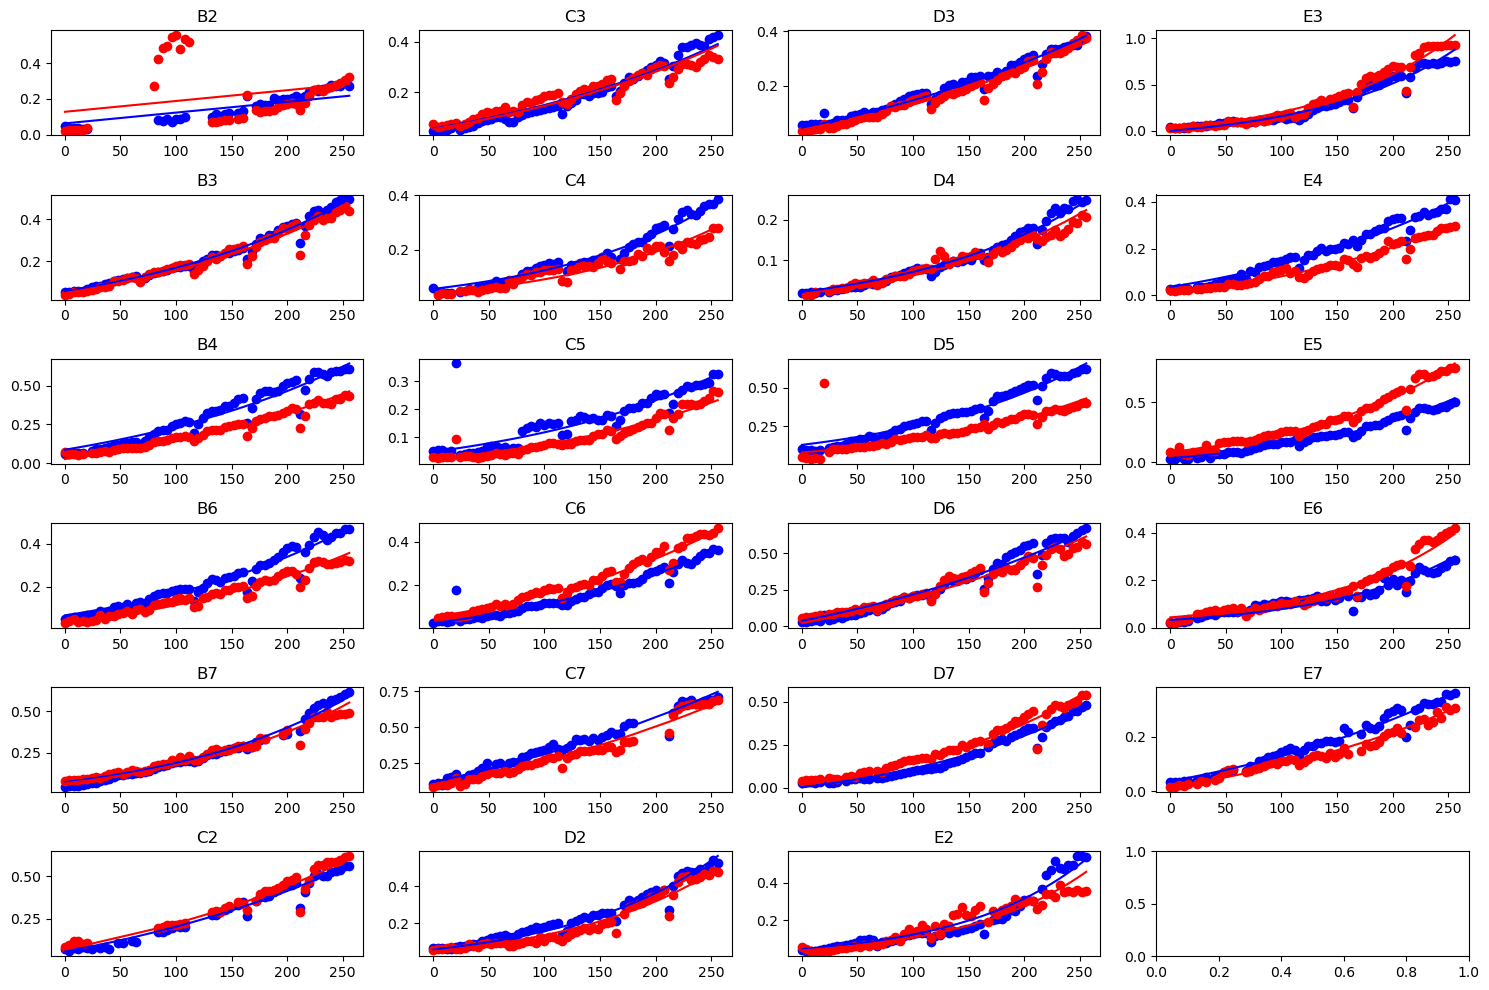

In [23]:
fig, axs = plt.subplots(6, 4, figsize=(15, 10))

for i, well in enumerate(wells):
    ax = axs[i%6, i//6]

    if well+'_1' not in exclude_wells:
        ax.scatter(
            times[well+'_1'],
            np.array([np.mean(confluence[well+'_1'][i, :, :edges[well+'_1']]) for i in range(len(times[well+'_1']))]),
            color='blue'
        )
        ax.plot(times[well+'_1'], growth_curve(np.array(times[well+'_1']), *params[well][[0, 2, 3]]), color='blue')

    if well+'_2' not in exclude_wells:
        ax.scatter(
            times[well+'_2'],
            np.array([np.mean(confluence[well+'_2'][i, :, :edges[well+'_2']]) for i in range(len(times[well+'_2']))]),
            color='red'
        )
        ax.plot(times[well+'_2'], growth_curve(np.array(times[well+'_2']), *params[well][[1, 2, 3]]), color='red')

    ax.set_title(well)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Growth rate (1/hr)')

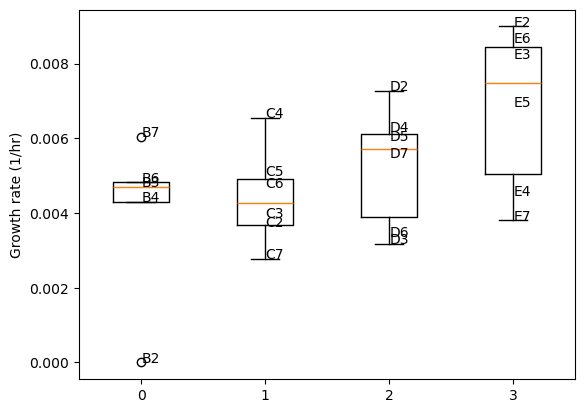

In [24]:
plt.boxplot(
    [[params[well][2] for well in wells if well[0] == 'B'],
     [params[well][2] for well in wells if well[0] == 'C'],
     [params[well][2] for well in wells if well[0] == 'D'],
     [params[well][2] for well in wells if well[0] == 'E']],
     positions=[0, 1, 2, 3],
)

for well in wells:
    plt.text(
        {'B':0, 'C':1, 'D':2, 'E':3}[well[0]],
        params[well][2],
        well
    )

plt.ylabel('Growth rate (1/hr)')

Text(0, 0.5, 'Migration rate (cells/hr)')

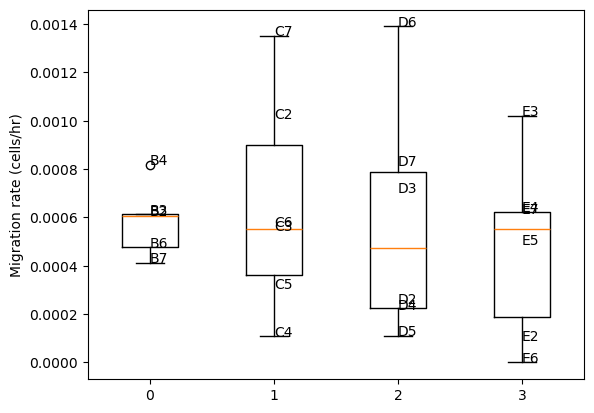

In [26]:
plt.boxplot(
    [[params[well][3] for well in wells if well[0] == 'B'],
     [params[well][3] for well in wells if well[0] == 'C'],
     [params[well][3] for well in wells if well[0] == 'D'],
     [params[well][3] for well in wells if well[0] == 'E']],
     positions=[0, 1, 2, 3],
)

for well in wells:
    plt.text(
        {'B':0, 'C':1, 'D':2, 'E':3}[well[0]],
        params[well][3],
        well
    )

plt.ylabel('Migration rate (cells/hr)')

## Shared k

In [27]:
images = np.array([well for well in confluence.keys() if well not in exclude_wells])
images

array(['B2_2', 'D7_1', 'E6_2', 'C4_1', 'E5_2', 'B7_2', 'D6_1', 'B4_2',
       'B3_2', 'E3_2', 'C2_1', 'D3_1', 'B6_1', 'E2_1', 'C7_1', 'D4_1',
       'D2_1', 'E4_1', 'D5_1', 'D4_2', 'C7_2', 'C6_2', 'D2_2', 'C5_2',
       'E7_1', 'C2_2', 'C4_2', 'D7_2', 'C3_2', 'B3_1', 'E3_1', 'E5_1',
       'E4_2', 'B4_1', 'B2_1', 'E2_2', 'B7_1', 'D6_2', 'E7_2', 'C6_1',
       'C5_1', 'C3_1', 'E6_1', 'B6_2', 'D3_2', 'D5_2'], dtype='<U4')

In [28]:
well_idx = np.array([np.where(wells == image[:2])[0][0] for image in images])
well_idx

array([ 0, 16, 21,  7, 20,  4, 15,  2,  1, 18,  5, 12,  3, 17, 10, 13, 11,
       19, 14, 13, 10,  9, 11,  8, 22,  5,  7, 16,  6,  1, 18, 20, 19,  2,
        0, 17,  4, 15, 22,  9,  8,  6, 21,  3, 12, 14])

In [29]:
ys = np.concatenate([[np.mean(confluence[well][i, :, :edges[well]]) for i in range(confluence[well].shape[0])] for well in images])
ys

array([0.02179537, 0.02426003, 0.0240505 , ..., 0.38388459, 0.40250449,
       0.39950091])

In [30]:
n0 = np.array([np.mean(confluence[well][0, :, :edges[well]]) for well in images])
n0

array([0.02179537, 0.02666508, 0.02577908, 0.05955572, 0.08149771,
       0.07604222, 0.03045075, 0.07041587, 0.04147001, 0.03043791,
       0.07382453, 0.05469708, 0.05117923, 0.03748223, 0.10449641,
       0.02070664, 0.0681396 , 0.02575874, 0.10083   , 0.01577419,
       0.08630559, 0.05176382, 0.05904779, 0.02627964, 0.03462039,
       0.08620542, 0.03506007, 0.03673133, 0.07321515, 0.05503907,
       0.03779695, 0.02726832, 0.0214807 , 0.06189653, 0.0459792 ,
       0.05396757, 0.04035937, 0.05917671, 0.01644981, 0.02843357,
       0.04859216, 0.04800231, 0.01983545, 0.0319174 , 0.0359182 ,
       0.04782237])

In [31]:
xs = np.concatenate([times[well] for well in images])
xs

array([  0,   4,   8, ..., 248, 252, 256])

In [32]:
x_idx = np.concatenate([np.repeat(i, len(times[well])) for i, well in enumerate(images)])
x_idx

array([ 0,  0,  0, ..., 45, 45, 45])

In [33]:
def growth_curve_all(t, n_0, k, m):
    return ((n_0*k + m[well_idx])[x_idx]*np.exp(k*t)-m[well_idx][x_idx])/k

def growth_curve_all_for_curve_fit(t, *l):
    return growth_curve_all(t, np.array(l[:len(images)]), l[len(images)], np.array(l[len(images)+1:])).flatten()

In [34]:
params = curve_fit(
    growth_curve_all_for_curve_fit,
    xs,
    ys,
    p0=np.append(n0, 0.1*np.ones(wells.shape[0]+1)),
    bounds=(0, 1)
)[0]
params

array([7.38296879e-02, 5.37842852e-03, 3.59497183e-02, 5.47673837e-02,
       7.82036677e-02, 6.22121812e-02, 6.39758116e-02, 4.76233685e-02,
       5.90668571e-02, 2.50622356e-02, 7.67071249e-02, 6.05390539e-02,
       7.15854225e-02, 2.35106817e-02, 1.44849496e-01, 2.22400828e-02,
       5.01738948e-02, 4.01048479e-02, 1.29254077e-01, 1.68128528e-02,
       1.24683013e-01, 5.75304545e-02, 3.57768380e-02, 2.60309362e-02,
       4.70754588e-02, 8.75280523e-02, 3.51695641e-02, 2.72966955e-02,
       6.51588538e-02, 6.54809812e-02, 1.03996570e-22, 1.73177070e-02,
       1.34736064e-02, 9.40116837e-02, 6.14380389e-02, 1.38545383e-02,
       7.03594729e-02, 5.03067360e-02, 3.06668969e-02, 3.38524362e-02,
       4.83846901e-02, 6.85957426e-02, 1.74754158e-02, 4.27605767e-02,
       5.40244333e-02, 7.82640322e-02, 5.79826307e-03, 4.55754799e-21,
       3.70729088e-04, 4.32532210e-04, 2.89290717e-04, 4.71951632e-04,
       4.30576717e-04, 1.80019769e-04, 2.16974127e-04, 2.04150275e-04,
      

In [35]:
n_0 = {image:params[i] for i, image in enumerate(images)}
n_0

{np.str_('B2_2'): np.float64(0.073829687943599),
 np.str_('D7_1'): np.float64(0.005378428521672397),
 np.str_('E6_2'): np.float64(0.03594971834861447),
 np.str_('C4_1'): np.float64(0.05476738366077071),
 np.str_('E5_2'): np.float64(0.07820366772382419),
 np.str_('B7_2'): np.float64(0.062212181216262784),
 np.str_('D6_1'): np.float64(0.06397581158932604),
 np.str_('B4_2'): np.float64(0.047623368534901026),
 np.str_('B3_2'): np.float64(0.05906685711111095),
 np.str_('E3_2'): np.float64(0.02506223556156099),
 np.str_('C2_1'): np.float64(0.07670712488207602),
 np.str_('D3_1'): np.float64(0.06053905390300164),
 np.str_('B6_1'): np.float64(0.07158542249295065),
 np.str_('E2_1'): np.float64(0.023510681652250627),
 np.str_('C7_1'): np.float64(0.14484949628859026),
 np.str_('D4_1'): np.float64(0.022240082784005983),
 np.str_('D2_1'): np.float64(0.05017389477398634),
 np.str_('E4_1'): np.float64(0.04010484793391567),
 np.str_('D5_1'): np.float64(0.12925407718709767),
 np.str_('D4_2'): np.float64

In [36]:
k = params[len(images)]
k

np.float64(0.005798263071710488)

In [37]:
m = {well:params[len(images)+1+i] for i, well in enumerate(wells)}
m

{np.str_('B2'): np.float64(4.557547992835986e-21),
 np.str_('B3'): np.float64(0.00037072908797486896),
 np.str_('B4'): np.float64(0.0004325322100740191),
 np.str_('B6'): np.float64(0.00028929071746426534),
 np.str_('B7'): np.float64(0.0004719516317368621),
 np.str_('C2'): np.float64(0.00043057671727176705),
 np.str_('C3'): np.float64(0.00018001976927980995),
 np.str_('C4'): np.float64(0.00021697412705187446),
 np.str_('C5'): np.float64(0.00020415027516133014),
 np.str_('C6'): np.float64(0.00037504228186656765),
 np.str_('C7'): np.float64(0.00025517684071575425),
 np.str_('D2'): np.float64(0.0005486228860686173),
 np.str_('D3'): np.float64(0.00023295638478386643),
 np.str_('D4'): np.float64(0.0002465694364824037),
 np.str_('D5'): np.float64(0.0001473019146877078),
 np.str_('D6'): np.float64(0.0006959143972054682),
 np.str_('D7'): np.float64(0.0007531897149442785),
 np.str_('E2'): np.float64(0.0006454647454885044),
 np.str_('E3'): np.float64(0.0014079599916886846),
 np.str_('E4'): np.flo

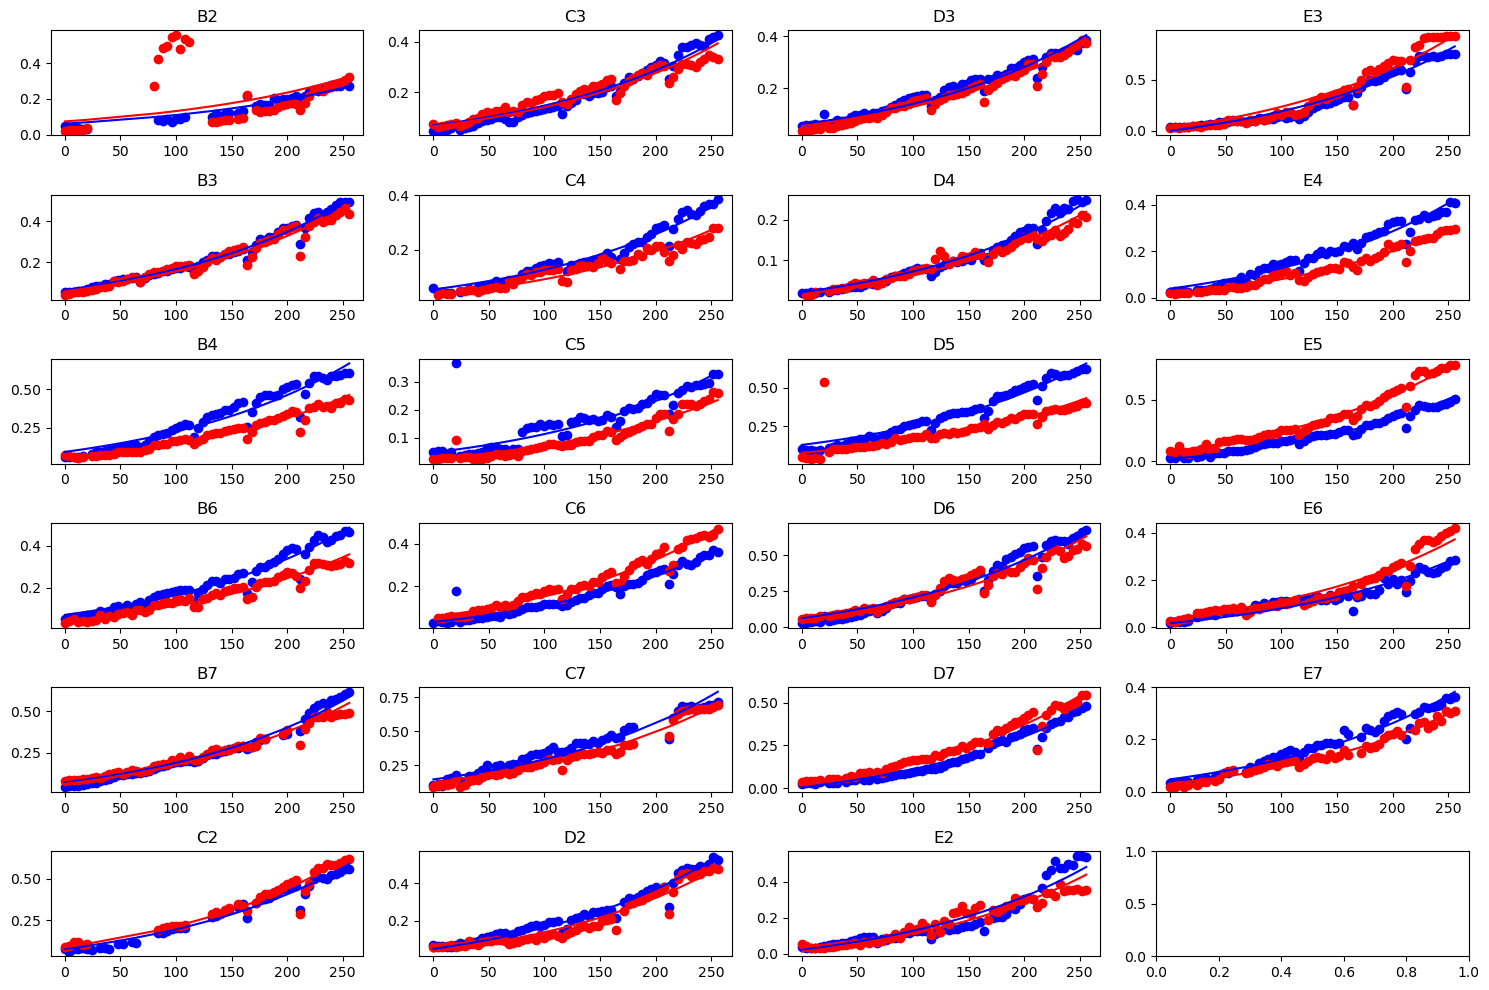

In [38]:
fig, axs = plt.subplots(6, 4, figsize=(15, 10))

for i, well in enumerate(wells):
    ax = axs[i%6, i//6]

    if well+'_1' not in exclude_wells:
        ax.scatter(
            times[well+'_1'],
            np.array([np.mean(confluence[well+'_1'][i, :, :edges[well+'_1']]) for i in range(len(times[well+'_1']))]),
            color='blue'
        )
        ax.plot(times[well+'_1'], growth_curve(np.array(times[well+'_1']), n_0[well+'_1'], k, m[well[:2]]), color='blue')

    if well+'_2' not in exclude_wells:
        ax.scatter(
            times[well+'_2'],
            np.array([np.mean(confluence[well+'_2'][i, :, :edges[well+'_2']]) for i in range(len(times[well+'_2']))]),
            color='red'
        )
        ax.plot(times[well+'_2'], growth_curve(np.array(times[well+'_2']), n_0[well+'_2'], k, m[well[:2]]), color='red')

    ax.set_title(well)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Migration rate (cells/hr)')

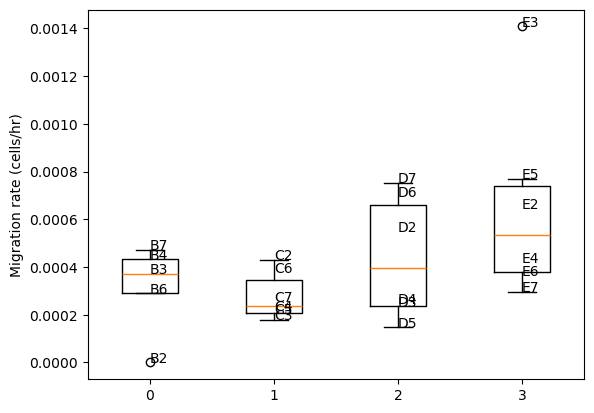

In [ ]:
plt.boxplot(
    [[m[well[:2]] for well in wells if well[0] == 'B'],
     [m[well[:2]] for well in wells if well[0] == 'C'],
     [m[well[:2]] for well in wells if well[0] == 'D'],
     [m[well[:2]] for well in wells if well[0] == 'E']],
     positions=[0, 1, 2, 3],
)

for well in wells:
    plt.text(
        {'B':0, 'C':1, 'D':2, 'E':3}[well[0]],
        m[well[:2]],
        well
    )

plt.ylabel('Migration rate')

In [ ]:
test_well = 'E5_2'
test_edge = 1000

In [ ]:
plt.imshow(phase[test_well][-1], cmap='gist_grey')
plt.imshow(left(confluence[test_well][-1], test_edge), cmap=confluence_cmap('red'))
plt.imshow(right(confluence[test_well][-1], test_edge), cmap=confluence_cmap('blue'))

KeyError: 'F4_2'